## Resources

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
data_path = "/content/dataset2"
this_folder = "/content/"

## Dataset Investigation

In [7]:
import os
import pandas as pd

image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')
image_count = 0

# Assuming images are in a subdirectory 'images' within data_path
images_dir = os.path.join(data_path, 'images')

if os.path.exists(images_dir):
    for root, _, files in os.walk(images_dir):
        for file in files:
            if file.lower().endswith(image_extensions):
                image_count += 1
else:
    print(f"Warning: '{images_dir}' not found. Please ensure your images are in the correct subdirectory.")

print(f"Total pictures found in '{images_dir}': {image_count}")

# Calculate 80/20 split
train_split = int(image_count * 0.8)
test_split = image_count - train_split

print(f"80/20 split: {train_split} for training, {test_split} for testing.")


Total pictures found in '/content/dataset2/images': 10809
80/20 split: 8647 for training, 2162 for testing.


In [8]:
csv_file_name = 'log.csv' # Corrected CSV file name
csv_path = os.path.join(data_path, csv_file_name)

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    num_rows_csv = len(df)
    print(f"Number of rows in '{csv_file_name}': {num_rows_csv}")
    # Check if number of rows matches image count + 1 (for header)
    if num_rows_csv == image_count + 1:
        print("Number of CSV rows matches image count + 1 (header). Headers are not included in the row count.")
    elif num_rows_csv == image_count:
        print("Number of CSV rows matches image count. There is no header.")
    else:
        print(f"Mismatch: CSV rows ({num_rows_csv}) do not match image count ({image_count}) + 1 header row. Please check your data.")
    display(df.head())
else:
    print(f"Error: CSV file '{csv_file_name}' not found at '{csv_path}'. Please specify the correct CSV file name or path.")

Number of rows in 'log.csv': 10809
Number of CSV rows matches image count. There is no header.


,timestamp,image_filename,vel_left,vel_right,intent,w,a,s,d
0,1.782994e+09,1782993540.4203.jpg,0.150827,0.175285,lane_following,1,0,0,0
1,1.782994e+09,1782993540.5193.jpg,0.150827,0.175285,lane_following,1,0,0,0
2,1.782994e+09,1782993540.6179.jpg,0.150827,0.175285,lane_following,1,0,0,0
3,1.782994e+09,1782993540.7178.jpg,0.150827,0.175285,lane_following,1,0,0,0
4,1.782994e+09,1782993540.8443.jpg,0.150827,0.175285,lane_following,1,0,0,0


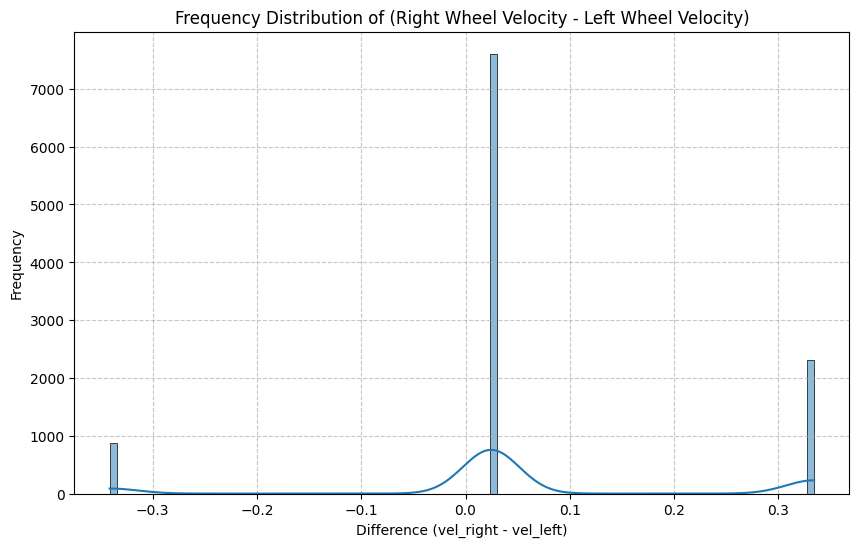

Descriptive statistics for 'diff':


,diff
count,10809.000000
mean,0.060993
std,0.173689
min,-0.341253
25%,0.024458
50%,0.024458
75%,0.024458
max,0.334265


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define diff = vel_right - vel_left
df['diff'] = df['vel_right'] - df['vel_left']

# Create a histogram to visualize the frequency of each diff
plt.figure(figsize=(10, 6))
sns.histplot(df['diff'], bins=100, kde=True)
plt.title('Frequency Distribution of (Right Wheel Velocity - Left Wheel Velocity)')
plt.xlabel('Difference (vel_right - vel_left)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Descriptive statistics for 'diff':")
display(df['diff'].describe())

In [10]:
import pandas as pd

# EPSILON is already defined in the kernel state (0.2)
# If you wish to change it, uncomment and modify the line below:
EPSILON = 0.05 # Example: a 0.05 m/s difference in wheel velocity

def classify_turn_from_diff(diff_value):
    if abs(diff_value) <= EPSILON:
        return 0 # Straight
    elif diff_value > EPSILON:
        return 1 # Left turn (right wheel significantly faster)
    else: # diff_value < -EPSILON
        return 2 # Right turn (left wheel significantly faster)

# Apply the classification function to the 'diff' column
df['turn_classification'] = df['diff'].apply(classify_turn_from_diff)

print("\nFrequency of 'turn_classification' classes:")
turn_classification_counts = df['turn_classification'].value_counts(normalize=True) * 100
print(turn_classification_counts.sort_index().to_string())


Frequency of 'turn_classification' classes:
turn_classification
0    70.395041
1    21.435841
2     8.169118


In [11]:
if 'df' in locals() and not df.empty:
    if 'intent' in df.columns:
        print("\nOccurrences of each 'intent' value (in %):")
        intend_counts = df['intent'].value_counts(normalize=True) * 100
        print(intend_counts.to_string())
    else:
        print("Column 'intent' not found in the CSV.")
else:
    print("DataFrame not loaded or is empty. Cannot analyze 'intend' column.")


Occurrences of each 'intent' value (in %):
intent
lane_following    73.022481
left              10.519012
straight          10.361736
right              6.096771


In [12]:
if 'df' in locals() and not df.empty:
    control_columns = ['w', 'a', 's', 'd']
    print("\nPercentage of '1's in control columns (w, a, s, d):")
    for col in control_columns:
        if col in df.columns:
            # Assuming 0/1 binary values
            if df[col].isin([0, 1]).all():
                one_percentage = (df[col].sum() / len(df)) * 100
                print(f"  {col}: {one_percentage:.2f}%")
            else:
                print(f"  Warning: Column '{col}' contains values other than 0 or 1. Summing all non-zero values.")
                one_percentage = (df[col] != 0).sum() / len(df) * 100
                print(f"  {col}: {one_percentage:.2f}% (non-zero)")
        else:
            print(f"  Column '{col}' not found in the CSV.")
else:
    print("DataFrame not loaded or is empty. Cannot analyze control columns.")


Percentage of '1's in control columns (w, a, s, d):
  w: 100.00%
  a: 21.50%
  s: 0.00%
  d: 8.18%


In [13]:
if 'df' in locals() and not df.empty:
    if 'w' in df.columns and 'a' in df.columns:
        # Calculate co-occurrence of 'w' and 'a' being 1
        w_and_a_count = df[(df['w'] == 1) & (df['a'] == 1)].shape[0]
        w_and_a_percentage = (w_and_a_count / len(df)) * 100
        print(f"\nPercentage of times 'w' and 'a' are both 1: {w_and_a_percentage:.2f}%")
    else:
        print("Columns 'w' or 'a' not found in the CSV. Cannot calculate co-occurrence.")

    if 'w' in df.columns and 'd' in df.columns:
        # Calculate co-occurrence of 'w' and 'd' being 1
        w_and_d_count = df[(df['w'] == 1) & (df['d'] == 1)].shape[0]
        w_and_d_percentage = (w_and_d_count / len(df)) * 100
        print(f"Percentage of times 'w' and 'd' are both 1: {w_and_d_percentage:.2f}%")
    else:
        print("Columns 'w' or 'd' not found in the CSV. Cannot calculate co-occurrence.")
else:
    print("DataFrame not loaded or is empty. Cannot analyze co-occurrence.")


Percentage of times 'w' and 'a' are both 1: 21.50%
Percentage of times 'w' and 'd' are both 1: 8.18%


## inspect segModel

Loading segmentation model from: /content/yolo_best_256x320.pt
Segmentation model loaded successfully (YOLO format).
Model is running on device: cpu
Using random example image from dataset: /content/dataset2/images/1782994251.0178.jpg

0: 256x320 25.0ms
Speed: 0.8ms preprocess, 25.0ms inference, 4.1ms postprocess per image at shape (1, 3, 256, 320)

--- Segmentation Model Output Inspection ---
Original input image size (PIL): (640, 480) (Width, Height)
Model output type (semantic_mask.data): <class 'torch.Tensor'>
Model output shape (semantic_mask.data): torch.Size([480, 640]) (Batch, Height, Width)
Model output device (semantic_mask.data): cuda:0
Model output data type (semantic_mask.data): torch.uint8
Unique values in predicted mask (on CPU): [0 1 3]


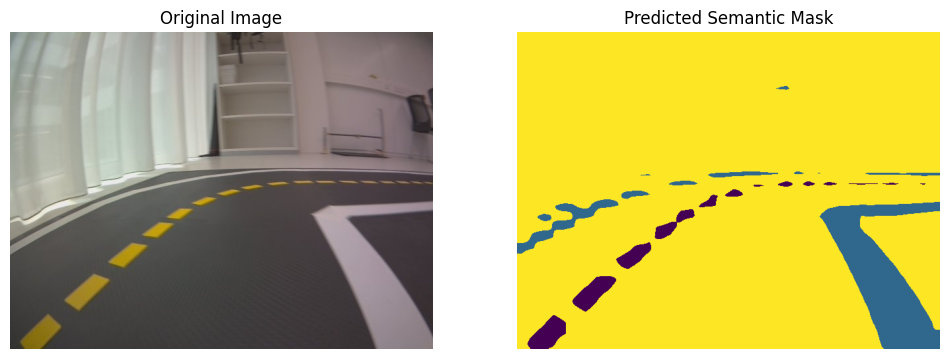

In [15]:
import os
import torch
from PIL import Image
import numpy as np
import random
import glob

# Ensure ultralytics is installed for YOLO model operations
try:
    from ultralytics import YOLO
except ImportError:
    print("ultralytics not found. Installing...")
    !pip install ultralytics
    from ultralytics import YOLO

# Define the path to the segmentation model based on user's request
seg_model_filename = 'yolo_best_256x320.pt'
seg_model_path = os.path.join(this_folder, seg_model_filename)

if not os.path.exists(seg_model_path):
    print(f"Error: Segmentation model '{seg_model_filename}' not found at {seg_model_path}.")
    print("Attempting to find 'best.pt' or 'last.pt' from a YOLO training run in 'this_folder'.")

    # Fallback to common YOLO saved model names
    fallback_paths = [
        os.path.join(this_folder, 'best.pt'),
        os.path.join(this_folder, 'last.pt'),
        # If the user trained a YOLO model, it might be in a 'runs' directory
        # This assumes a specific run name, which might not always be accurate
        # os.path.join(this_folder, 'runs', 'lane_marking_segmentation', 'weights', 'best.pt'),
        # os.path.join(this_folder, 'runs', 'lane_marking_segmentation', 'weights', 'last.pt'),
    ]
    found_fallback = False
    for fp in fallback_paths:
        if os.path.exists(fp):
            seg_model_path = fp
            seg_model_filename = os.path.basename(fp)
            print(f"Found fallback model: {seg_model_path}")
            found_fallback = True
            break

    if not found_fallback:
        raise FileNotFoundError(f"No segmentation model found at {seg_model_path} or common fallback paths. Please ensure your model is correctly saved and named.")

print(f"Loading segmentation model from: {seg_model_path}")

try:
    # Load the YOLO model
    model = YOLO(seg_model_path, task="semantic")
    print("Segmentation model loaded successfully (YOLO format).")
    print(f"Model is running on device: {model.device}")

    # Prepare an example image for inference
    example_img = None
    if 'images_dir' in globals() and os.path.exists(images_dir):
        # Check if images_dir actually contains image files
        image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            random_image_path = os.path.join(images_dir, random.choice(image_files))
            print(f"Using random example image from dataset: {random_image_path}")
            example_img = Image.open(random_image_path).convert('RGB')
        else:
            print(f"No image files found in '{images_dir}'. Creating a dummy image.")

    if example_img is None:
        # From user context, imgsz=(480,640) was used for training (height, width)
        dummy_height, dummy_width = 480, 640
        print(f"Creating a dummy {dummy_width}x{dummy_height} RGB image for inference.")
        example_img = Image.new('RGB', (dummy_width, dummy_height), color='red') # PIL Image expects (width, height)

    # Perform inference
    results = model(example_img) # YOLO model handles resizing internally

    # Inspect the outputs if semantic_mask is present
    if results and hasattr(results[0], 'semantic_mask'):
        predicted_mask = results[0].semantic_mask.data # This is typically a torch.Tensor
        predicted_mask_numpy = predicted_mask.cpu().numpy()

        print(f"\n--- Segmentation Model Output Inspection ---")
        print(f"Original input image size (PIL): {example_img.size} (Width, Height)")
        print(f"Model output type (semantic_mask.data): {type(predicted_mask)}")
        print(f"Model output shape (semantic_mask.data): {predicted_mask.shape} (Batch, Height, Width)")
        print(f"Model output device (semantic_mask.data): {predicted_mask.device}")
        print(f"Model output data type (semantic_mask.data): {predicted_mask.dtype}")
        print(f"Unique values in predicted mask (on CPU): {np.unique(predicted_mask_numpy)}")

        # Basic visualization if matplotlib is available (no complex colormap assumed)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(example_img)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(predicted_mask_numpy)
        plt.title('Predicted Semantic Mask')
        plt.axis('off')
        plt.show()

    elif results:
        print("\nModel produced results, but 'semantic_mask' attribute was not found in the first result object.")
        print(f"Available attributes on results[0]: {[attr for attr in dir(results[0]) if not attr.startswith('__')]}")
        print("This might happen if the YOLO model was not specifically trained for segmentation or if the output format is different than expected.")
    else:
        print("Model inference returned no results.")

except Exception as e:
    print(f"An error occurred during model loading or inference: {e}")
    print("Please ensure ultralytics is installed and the model file is a valid YOLO segmentation model. Also check if the model architecture is compatible.")


## Training

### Utils

In [21]:
import torchvision.transforms as transforms
import os

# Ensure YOLO is imported from ultralytics
try:
    from ultralytics import YOLO
except ImportError:
    print("ultralytics not found. Installing...")
    !pip install ultralytics
    from ultralytics import YOLO

# Preprocessing Constants
CROP_TOP_ROWS = 175
INPUT_SHAPE = (112, 224) # Height, Width

# Intent mapping for one-hot encoding
INTENT_MAP = {
    "straight": [1.0, 0.0, 0.0, 0.0],
    "left":     [0.0, 1.0, 0.0, 0.0],
    "right":    [0.0, 0.0, 1.0, 0.0],
    "stop":     [0.0, 0.0, 0.0, 1.0]
}

def crop_image(pil_image):
    width, height = pil_image.size
    # Ensure cropping does not result in negative height
    crop_height = height - CROP_TOP_ROWS
    if crop_height <= 0:
        # If the image is too short, just return it or handle as an error
        print(f"Warning: Image height {height} is too small for CROP_TOP_ROWS {CROP_TOP_ROWS}. Not cropping.")
        return pil_image
    return pil_image.crop((0, CROP_TOP_ROWS, width, height))

# Transforms for segmentation masks (no augmentations as requested)
def get_train_mask_transforms():
    return transforms.Compose([
        transforms.Resize(INPUT_SHAPE, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(), # Converts PIL to FLoatTensor and scales to [0.0, 1.0]
    ])

def get_eval_mask_transforms():
    return transforms.Compose([
        transforms.Resize(INPUT_SHAPE, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(), # Converts PIL to FLoatTensor and scales to [0.0, 1.0]
    ])

def get_yolo_model(model_folder: str):
    """
    Loads the YOLO segmentation model from the specified folder.
    Includes fallback logic for common YOLO model names.
    """
    seg_model_filename = 'yolo_best_256x320.pt'
    seg_model_path = os.path.join(model_folder, seg_model_filename)

    print(f"Loading YOLO segmentation model from: {seg_model_path}")
    model = YOLO(seg_model_path, task="semantic") # Load as YOLO object
    #model.eval() # Set to evaluation mode to freeze weights and disable dropout/batchnorm updates
    return model


### PilotNet Model

In [17]:
import torch
import torch.nn as nn


class FiLM(nn.Module):
    """
    Feature-wise Linear Modulation.

    Predicts a per-channel gamma/beta pair from a conditioning embedding and
    applies gamma * x + beta. Works for conv feature maps (B, C, H, W) -
    broadcasting gamma/beta over spatial dims - and for flat vectors (B, C).
    """
    def __init__(self, embedding_dim: int, num_features: int):
        super().__init__()
        self.gamma_fc = nn.Linear(embedding_dim, num_features)
        self.beta_fc = nn.Linear(embedding_dim, num_features)
        # Identity-ish init (gamma=1, beta=0) so FiLM starts as a no-op and
        # doesn't destabilize training before the conditioning is learned -
        # this matters more here since we stack several FiLM layers.
        nn.init.zeros_(self.gamma_fc.weight)
        nn.init.ones_(self.gamma_fc.bias)
        nn.init.zeros_(self.beta_fc.weight)
        nn.init.zeros_(self.beta_fc.bias)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        gamma = self.gamma_fc(cond)
        beta = self.beta_fc(cond)
        if x.dim() == 4:
            gamma = gamma.unsqueeze(-1).unsqueeze(-1)
            beta = beta.unsqueeze(-1).unsqueeze(-1)
        return gamma * x + beta


class ConditionalPilotNetFiLM(nn.Module):
    def __init__(self, intent_dim: int = 4, cond_embedding_dim: int = 64):
        super().__init__()

        # --- Shared intent encoder ---
        # One small embedding shared by every FiLM layer downstream, each FiLM layer
        # below has its own lightweight linear head off this shared embedding.
        self.intent_encoder = nn.Sequential(
            nn.Linear(intent_dim, cond_embedding_dim),
            nn.ReLU(),
        )

        # --- Early conv layers: unconditioned ---
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 24, kernel_size=5, stride=2), nn.BatchNorm2d(24), nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2), nn.BatchNorm2d(36), nn.ReLU(),
        )

        # --- Deeper conv layers: FiLM-conditioned ---
        self.conv3 = nn.Conv2d(36, 48, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm2d(48)
        self.film3 = FiLM(cond_embedding_dim, 48)

        self.conv4 = nn.Conv2d(48, 64, kernel_size=3, stride=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.film4 = FiLM(cond_embedding_dim, 64)

        self.conv5 = nn.Conv2d(64, 48, kernel_size=3, stride=1)
        self.bn5 = nn.BatchNorm2d(48)
        self.film5 = FiLM(cond_embedding_dim, 48)

        self.act = nn.ReLU()

        # --- Dimensionality reduction ---
        self.pool = nn.AdaptiveAvgPool2d((4, 7))
        self.flattened_size = 48 * 4 * 7  # 1344

        # --- Bottleneck: explicit compression + FiLM on a "linear layer" ---
        self.bottleneck_dim = 128
        self.bottleneck_fc = nn.Linear(self.flattened_size, self.bottleneck_dim)
        self.film_bottleneck = FiLM(cond_embedding_dim, self.bottleneck_dim)

        # --- Regression head ---
        self.head = nn.Sequential(
            nn.Linear(self.bottleneck_dim, 50),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(50, 10),
            nn.ReLU(),
            nn.Linear(10, 2),
        )

    def forward(self, img: torch.Tensor, intent: torch.Tensor) -> torch.Tensor:
        cond = self.intent_encoder(intent)  # (B, cond_embedding_dim), shared by all FiLM layers below

        x = self.conv1(img)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.film3(x, cond)
        x = self.act(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.film4(x, cond)
        x = self.act(x)

        x = self.conv5(x)
        x = self.bn5(x)
        x = self.film5(x, cond)
        x = self.act(x)

        x = self.pool(x)
        x = x.reshape(x.size(0), -1)

        x = self.bottleneck_fc(x)
        x = self.film_bottleneck(x, cond)
        x = self.act(x)

        output_velocities = self.head(x)
        return output_velocities

In [18]:
model_instance = ConditionalPilotNetFiLM()
sum(p.numel() for p in model_instance.parameters() if p.requires_grad)

338258

### Dataset

In [39]:
import os
import random
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as TF
import pandas as pd

# Assumes ConditionalPilotNet, get_train_mask_transforms, get_eval_mask_transforms, crop_image, INTENT_MAP are defined above

class DuckieTownDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, yolo_model=None, oversample_train_classes=False):
        self.image_dir = image_dir
        self.transform = transform
        self.yolo_model = yolo_model

        if self.yolo_model is None:
            raise ValueError("YOLO segmentation model must be provided to the DuckieTownDataset.")
        self.yolo_model.eval()

        if oversample_train_classes:
            print("Applying custom intent oversampling (40% LF, 20% L, 20% S, 20% R)...")

            # Target percentages
            targets = {
                'lane_following': 0.40,
                'left': 0.20,
                'straight': 0.20,
                'right': 0.20
            }

            # Group by intent
            groups = {intent: dataframe[dataframe['intent'] == intent] for intent in targets.keys()}

            # Determine size based on the most over-represented class (lane_following usually)
            # To ensure we don't lose data, we scale based on the largest group relative to its target
            current_counts = dataframe['intent'].value_counts()
            max_needed = 0
            for intent, target_pct in targets.items():
                if intent in current_counts:
                    # How many total samples would we need if this class was the bottleneck?
                    needed_total = current_counts[intent] / target_pct
                    max_needed = max(max_needed, needed_total)

            # Use a reasonable total size (e.g., keeping at least the original count or scaling up)
            total_size = int(max(len(dataframe), max_needed))

            balanced_frames = []
            for intent, target_pct in targets.items():
                n_samples = int(total_size * target_pct)
                if n_samples > 0:
                    group_df = groups[intent]
                    if len(group_df) == 0:
                        print(f"Warning: No samples found for intent '{intent}'.")
                        continue
                    # Resample with replacement to hit the specific percentage
                    resampled = group_df.sample(n=n_samples, replace=True, random_state=42)
                    balanced_frames.append(resampled)

            self.dataframe = pd.concat(balanced_frames).sample(frac=1, random_state=42).reset_index(drop=True)
            print(f"Oversampling complete. New dataset size: {len(self.dataframe)}")
            print("New intent distribution (%):")
            print(self.dataframe['intent'].value_counts(normalize=True) * 100)
        else:
            self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        raw_img_name = os.path.join(self.image_dir, self.dataframe.iloc[idx]['image_filename'])
        raw_image = Image.open(raw_img_name).convert('RGB')

        with torch.no_grad():
            yolo_results = self.yolo_model(raw_image, verbose=False)

        if not yolo_results or not hasattr(yolo_results[0], 'semantic_mask'):
            yolo_output_h, yolo_output_w = 480, 640
            segmentation_mask_tensor = torch.zeros(yolo_output_h, yolo_output_w, dtype=torch.uint8)
        else:
            segmentation_mask_tensor = yolo_results[0].semantic_mask.data.cpu()

        mask_pil = Image.fromarray(segmentation_mask_tensor.numpy())

        vel_left = self.dataframe.iloc[idx]['vel_left']
        vel_right = self.dataframe.iloc[idx]['vel_right']
        intent_str = self.dataframe.iloc[idx]['intent']

        target_vel = torch.tensor([vel_left, vel_right], dtype=torch.float32)
        intent_tensor = torch.tensor(INTENT_MAP.get(intent_str, [1.0, 0.0, 0.0, 0.0]), dtype=torch.float32)

        cropped_mask_pil = crop_image(mask_pil)

        # Horizontal Flip logic
        if self.transform == get_train_mask_transforms() and random.random() > 0.5:
            cropped_mask_pil = TF.hflip(cropped_mask_pil)
            target_vel = torch.tensor([vel_right, vel_left], dtype=torch.float32)
            if intent_str == "left": intent_str = "right"
            elif intent_str == "right": intent_str = "left"
            intent_tensor = torch.tensor(INTENT_MAP.get(intent_str, [1.0, 0.0, 0.0, 0.0]), dtype=torch.float32)

        if self.transform:
            processed_mask_tensor = self.transform(cropped_mask_pil)
        else:
            processed_mask_tensor = transforms.ToTensor()(cropped_mask_pil)

        # Ensure the processed_mask_tensor requires gradients for the PilotNet model
        #processed_mask_tensor = processed_mask_tensor.requires_grad_(True)

        return processed_mask_tensor, intent_tensor, target_vel

In [36]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Assuming data_path, images_dir, and this_folder are defined from previous cells.
# Assuming DuckieTownDataset, get_train_mask_transforms, and get_yolo_model are defined.
# Assuming EPSILON and classify_turn_from_diff are defined.

# Reload logs_df and apply turn_classification for the sanity check
logs_filepath = os.path.join(data_path, 'log.csv')
logs_df_for_check = pd.read_csv(logs_filepath)

# Recalculate 'diff' and 'turn_classification' columns on the fresh df
logs_df_for_check['diff'] = logs_df_for_check['vel_right'] - logs_df_for_check['vel_left']
logs_df_for_check['turn_classification'] = logs_df_for_check['diff'].apply(classify_turn_from_diff)

# Split into train and val to isolate training data for oversampling check
train_df_for_check, _ = train_test_split(logs_df_for_check, test_size=0.2, random_state=42)

print("--- Sanity Check: Oversampling in DuckieTownDataset ---")

# --- 1. Without Oversampling ---
print("\nOriginal training data 'turn_classification' distribution:")
original_counts = train_df_for_check['turn_classification'].value_counts(normalize=True) * 100
print(original_counts.sort_index().to_string())
print(f"Original training dataset size: {len(train_df_for_check)}")

# --- 2. With Oversampling ---
# Load YOLO model once for both dataset instances
yolo_seg_model_check = get_yolo_model(this_folder)

# Create a dataset instance with oversampling enabled
# Pass the train_df to simulate what would be passed to the training loop
oversampled_dataset = DuckieTownDataset(
    train_df_for_check,
    images_dir,
    transform=get_train_mask_transforms(),
    yolo_model=yolo_seg_model_check,
    oversample_train_classes=True
)

print("\nOversampled training data 'turn_classification' distribution:")
# The dataset's internal dataframe should now be balanced
oversampled_counts = oversampled_dataset.dataframe['turn_classification'].value_counts(normalize=True) * 100
print(oversampled_counts.sort_index().to_string())
print(f"Oversampled training dataset size: {len(oversampled_dataset)}")

print("\n--- Sanity Check Complete ---")

--- Sanity Check: Oversampling in DuckieTownDataset ---

Original training data 'turn_classification' distribution:
turn_classification
0    70.648780
1    21.429397
2     7.921823
Original training dataset size: 8647
Loading YOLO segmentation model from: /content/yolo_best_256x320.pt
Applying custom intent oversampling (40% LF, 20% L, 20% S, 20% R)...
Oversampling complete. New dataset size: 15825
New intent distribution (%):
intent
lane_following    40.0
left              20.0
right             20.0
straight          20.0
Name: proportion, dtype: float64

Oversampled training data 'turn_classification' distribution:
turn_classification
0    63.797788
1    21.213270
2    14.988942
Oversampled training dataset size: 15825

--- Sanity Check Complete ---


### Training Script

In [40]:
import os
import time
import torch
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.multiprocessing as mp
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Assumes ConditionalPilotNet, DuckieTownDataset, get_train_mask_transforms, get_eval_mask_transforms, get_yolo_model are defined above

def train_model(data_path, epochs=10, batch_size=64, learning_rate=0.001):
    """Handles Data Loading, Training, Validation, and Saving PyTorch weights,
    and returns training/validation losses for plotting.

    The ConditionalPilotNet is now trained on segmentation masks from a frozen YOLO model.
    """
    # Set the multiprocessing start method to 'spawn' for CUDA compatibility
    # This needs to be called once at the beginning of the program if using multiprocessing with CUDA
    try:
        mp.set_start_method('spawn', force=True)
    except RuntimeError:
        pass # Already set

    images_folder = os.path.join(data_path, 'images')
    logs_filepath = os.path.join(data_path, 'log.csv')

    print("Loading dataset...")
    logs_df = pd.read_csv(logs_filepath)
    train_df, val_df = train_test_split(logs_df, test_size=0.2, random_state=42)
    print(f"Training set: {len(train_df)} | Validation set: {len(val_df)}")

    # Load and freeze the YOLO segmentation model once
    # Use 'this_folder' as the location for segModel.pt as per previous context
    global this_folder
    yolo_seg_model = get_yolo_model(this_folder)
    yolo_seg_model.eval() # Ensure it's in evaluation mode and frozen
    print("YOLO segmentation model loaded and frozen for feature extraction.")

    train_dataset = DuckieTownDataset(
        train_df, images_folder, transform=get_train_mask_transforms(), yolo_model=yolo_seg_model
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    val_dataset = DuckieTownDataset(
        val_df, images_folder, transform=get_eval_mask_transforms(), yolo_model=yolo_seg_model
    )
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNetFiLM().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.MSELoss()

    # Initialize learning rate scheduler
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses = []
    val_losses = []

    # Calculate initial validation loss (performance of fresh initialized model)
    model.eval()
    initial_val_loss = 0.0
    with torch.no_grad():
        for images, intents, targets in val_loader:
            images, intents, targets = images.to(device), intents.to(device), targets.to(device)
            outputs = model(images, intents)
            loss = criterion(outputs, targets)
            initial_val_loss += loss.item() * images.size(0)
    initial_val_loss /= len(val_loader.dataset)
    val_losses.append(initial_val_loss) # Add to list for plotting
    print(f"Initial Validation Loss: {initial_val_loss:.4f}")

    print(f"Training Started on device: {device}...")
    best_val_loss = float('inf')

    # Use 'this_folder' for saving models
    os.makedirs(this_folder, exist_ok=True) # Ensure the directory exists
    best_pth_path = os.path.join(this_folder, "best_film_model.pt") # Changed to .pt
    last_pth_path = os.path.join(this_folder, "last_film_model.pt")   # Changed to .pt

    #try:
    for epoch in range(epochs):
        epoch_start_time = time.time()

        # --- TRAIN ---
        model.train()
        running_train_loss = 0.0
        for images, intents, targets in train_loader:
            images, intents, targets = images.to(device), intents.to(device), targets.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(True):
              outputs = model(images, intents)
              loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        avg_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # --- VALIDATE ---
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, intents, targets in val_loader:
                images, intents, targets = images.to(device), intents.to(device), targets.to(device)
                outputs = model(images, intents)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * images.size(0)

        avg_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss) # Add to list for plotting

        # Step the learning rate scheduler
        scheduler.step(avg_val_loss)

        epoch_duration = time.time() - epoch_start_time

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_duration:.2f}s")

        # --- SAVE BEST ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_pth_path)
            print(f"   [*] New best validation loss! Saved best_model.pt to {this_folder}") # Updated message

    # except Exception as e:
    #     print(f"Error during training: {e}")
    # finally:
    #     # --- SAVE LAST --- Always save the last state if interrupted or finished
    #     torch.save(model.state_dict(), last_pth_path)
    #     print(f"Training Complete/Interrupted. Saved last_model.pt to {this_folder}") # Updated message
    #     return train_losses, val_losses

    # This part is reached if training completes without interruption
    print(f"\nTraining Complete. Saved last_model.pt to {this_folder}") # Updated message
    return train_losses, val_losses

## Training Pipeline Execution and Visualization

In [41]:
import matplotlib.pyplot as plt

# Call the train_model function and store the returned losses
train_losses, val_losses = train_model(data_path, epochs=100, batch_size=64, learning_rate=0.001)

# Plotting Training and Validation Loss
if 'train_losses' in locals() and 'val_losses' in locals():
    # Epochs range needs to account for the initial validation loss (epoch -1)
    epochs_range = range(-1, len(train_losses))

    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, val_losses, label='Validation Loss') # Plot validation loss first to include initial loss
    plt.plot(range(len(train_losses)), train_losses, label='Training Loss') # Training loss starts from epoch 0

    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch (Initial Loss at Epoch -1)')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.xticks(epochs_range) # Ensure all epoch markers are shown
    plt.show()
else:
    print("Training and validation losses not available for plotting. Please uncomment and run `train_model` first.")

Loading dataset...
Training set: 8647 | Validation set: 2162
Loading YOLO segmentation model from: /content/yolo_best_256x320.pt
YOLO segmentation model loaded and frozen for feature extraction.
Initial Validation Loss: 0.0306
Training Started on device: cuda...
Epoch 1/100 | Train Loss: 0.0057 | Val Loss: 0.0045 | Time: 91.82s
   [*] New best validation loss! Saved best_model.pt to /content/
Epoch 2/100 | Train Loss: 0.0044 | Val Loss: 0.0038 | Time: 91.40s
   [*] New best validation loss! Saved best_model.pt to /content/
Epoch 3/100 | Train Loss: 0.0041 | Val Loss: 0.0037 | Time: 91.37s
   [*] New best validation loss! Saved best_model.pt to /content/
Epoch 4/100 | Train Loss: 0.0040 | Val Loss: 0.0041 | Time: 90.11s
Epoch 5/100 | Train Loss: 0.0040 | Val Loss: 0.0041 | Time: 82.33s


KeyboardInterrupt: 

## Model Evaluation: Predictions on Example Images

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from PIL import Image
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Assumes ConditionalPilotNet, DuckieTownDataset, get_eval_mask_transforms, get_yolo_model, crop_image are defined above

# --- 1. Load ConditionalPilotNet model ---
model_path = os.path.join(this_folder, 'best_model.pth')

if not os.path.exists(model_path):
    print(f"Error: ConditionalPilotNet model not found at {model_path}. Please train the model first.")
    model = None
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNet().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Set model to evaluation mode
    print(f"Loaded ConditionalPilotNet from {model_path}")

# --- 2. Load YOLO Segmentation Model ---
yolo_seg_model = None
try:
    yolo_seg_model = get_yolo_model(this_folder)
    #yolo_seg_model.eval()
    print("YOLO segmentation model loaded for feature extraction.")
except FileNotFoundError as e:
    print(f"Error loading YOLO model: {e}")


if model and yolo_seg_model:
    # --- 3. Prepare a validation dataset and loader ---
    images_folder = os.path.join(data_path, 'images')
    logs_filepath = os.path.join(data_path, 'log.csv')
    logs_df = pd.read_csv(logs_filepath)
    _, val_df = train_test_split(logs_df, test_size=0.2, random_state=42)

    # Instantiate DuckieTownDataset with the YOLO model
    val_dataset = DuckieTownDataset(val_df, images_folder, transform=get_eval_mask_transforms(), yolo_model=yolo_seg_model)

    print("Displaying predictions for 10 random validation images:")

    # Select 10 random indices from the validation set
    random_indices = random.sample(range(len(val_dataset)), 10)

    fig, axes = plt.subplots(10, 2, figsize=(15, 40))
    fig.suptitle('Model Predictions vs. Ground Truth (Validation Set)', y=1.02)

    with torch.no_grad():
        for i, idx in enumerate(random_indices):
            # The `image` from val_dataset is now the processed segmentation mask tensor
            processed_mask_tensor, intent_tensor, target_vel = val_dataset[idx]

            # Load original raw image for display (before any processing)
            original_img_filename = val_dataset.dataframe.iloc[idx]['image_filename']
            original_img_path = os.path.join(val_dataset.image_dir, original_img_filename)
            original_raw_pil_image = Image.open(original_img_path).convert('RGB')

            # Optionally, get the intermediate cropped mask for visualization
            with torch.no_grad():
                yolo_results_vis = yolo_seg_model(original_raw_pil_image, verbose=False)
            intermediate_mask_tensor = yolo_results_vis[0].semantic_mask.data.cpu() # [H, W], uint8
            intermediate_mask_pil = crop_image(Image.fromarray(intermediate_mask_tensor.numpy()))


            # Add batch dimension and move to device for ConditionalPilotNet input
            image_input = processed_mask_tensor.unsqueeze(0).to(device) # [1, 1, H, W]
            intent_input = intent_tensor.unsqueeze(0).to(device) # [1, 4]

            # Make prediction
            output_vel = model(image_input, intent_input).cpu().numpy().flatten()

            # Ground Truth
            gt_vel = target_vel.cpu().numpy()

            # Calculate error
            error = np.abs(output_vel - gt_vel)

            # Display
            ax0 = axes[i, 0]
            ax0.imshow(original_raw_pil_image)
            ax0.set_title(f"Raw Input Image: {original_img_filename}\nIntent: {val_dataset.dataframe.iloc[idx]['intent']}", fontsize=8)
            ax0.axis('off')

            ax1 = axes[i, 1]
            ax1.imshow(intermediate_mask_pil) # Display the cropped YOLO mask for context
            ax1.set_title(
                f"Cropped Mask\nGT: L={gt_vel[0]:.4f}, R={gt_vel[1]:.4f}\nPred: L={output_vel[0]:.4f}, R={output_vel[1]:.4f}\nError: L={error[0]:.4f}, R={error[1]:.4f}", fontsize=8
            )
            ax1.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Skipping model evaluation due to missing ConditionalPilotNet or YOLO model.")


### Export Script

In [ ]:
import os
import torch

# Assumes ConditionalPilotNet is defined above

def compile_to_onnx(model_folder):
    """Loads saved PyTorch weights and exports them to ONNX format.
    Adjusted for 1-channel segmentation mask input.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConditionalPilotNet().to(device)
    model.eval() # Ensure dropout layers are disabled for export

    # Define exact dummy inputs expected by the model for 1-channel mask
    dummy_img = torch.randn(1, 1, INPUT_SHAPE[0], INPUT_SHAPE[1]).to(device) # [1, 1, Height, Width]
    dummy_intent = torch.randn(1, 4).to(device)

    # Compile Best Model
    best_pth = os.path.join(model_folder, "best_model.pth")
    if os.path.exists(best_pth):
        try:
            model.load_state_dict(torch.load(best_pth, map_location=device))
            torch.onnx.export(
                model, (dummy_img, dummy_intent), os.path.join(model_folder, "best_model.onnx"),
                export_params=True, opset_version=11, # Use opset 11 as previously requested implicitly
                input_names=['image_input', 'intent_input'], output_names=['wheel_velocities'],
                dynamic_axes={'image_input': {0: 'batch_size'}, 'intent_input': {0: 'batch_size'}, 'wheel_velocities': {0: 'batch_size'}} # Add dynamic axes for batch size
            )
            print(f"SUCCESS: Exported best_model.onnx to {model_folder}")
        except Exception as e:
            print(f"Error exporting best_model.onnx: {e}")

    # Compile Last Model
    last_pth = os.path.join(model_folder, "last_model.pth")
    if os.path.exists(last_pth):
        try:
            model.load_state_dict(torch.load(last_pth, map_location=device))
            torch.onnx.export(
                model, (dummy_img, dummy_intent), os.path.join(model_folder, "last_model.onnx"),
                export_params=True, opset_version=11, # Use opset 11 as previously requested implicitly
                input_names=['image_input', 'intent_input'], output_names=['wheel_velocities'],
                dynamic_axes={'image_input': {0: 'batch_size'}, 'intent_input': {0: 'batch_size'}, 'wheel_velocities': {0: 'batch_size'}} # Add dynamic axes for batch size
            )
            print(f"SUCCESS: Exported last_model.onnx to {model_folder}")
        except Exception as e:
            print(f"Error exporting last_model.onnx: {e}")


In [ ]:
!pip install onnxscript
compile_to_onnx(this_folder)